# Exploratory Data Analysis (EDA) Dataset Audio


In [1]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Library siap digunakan!')

Library siap digunakan!


### 1. Mengekstrak Durasi Asli & Fitur Dasar


In [8]:
raw_dir = 'dataset/raw'
classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']

data_list = []
print('Mengekstrak data dari seluruh file...')
for folder_name in classes:
    files = glob.glob(os.path.join(raw_dir, folder_name, '*.*'))
    for file in files:
        try:
            y, sr = librosa.load(file, sr=16000)
            raw_duration = len(y) / sr
            y_trimmed, index = librosa.effects.trim(y, top_db=20)
            actual_duration = len(y_trimmed) / sr
            zcr = np.mean(librosa.feature.zero_crossing_rate(y_trimmed))
            data_list.append({
                'Kelas': folder_name.upper(),
                'Durasi Awal (s)': raw_duration,
                'Durasi Asli Ucapan (s)': actual_duration,
                'ZCR (Kasar/Halus)': zcr,
                'Path': file
            })
        except:
            pass

df = pd.DataFrame(data_list)
print(f'Selesai! Berhasil memuat {len(df)} file audio.')
df.head()


Mengekstrak data dari seluruh file...
Selesai! Berhasil memuat 630 file audio.


,Kelas,Durasi Awal (s),Durasi Asli Ucapan (s),ZCR (Kasar/Halus),Path
0,HORAS,5.0,0.512,0.149816,dataset/raw\horas\horas-01.mp3
1,HORAS,5.0,0.512,0.108743,dataset/raw\horas\horas-02.mp3
2,HORAS,5.0,0.352,0.112752,dataset/raw\horas\horas-03.mp3
3,HORAS,5.0,1.152,0.115089,dataset/raw\horas\horas-04.mp3
4,HORAS,5.0,0.416,0.113665,dataset/raw\horas\horas-05.mp3


### 2. Distribusi Jumlah Data (Keseimbangan Kelas)

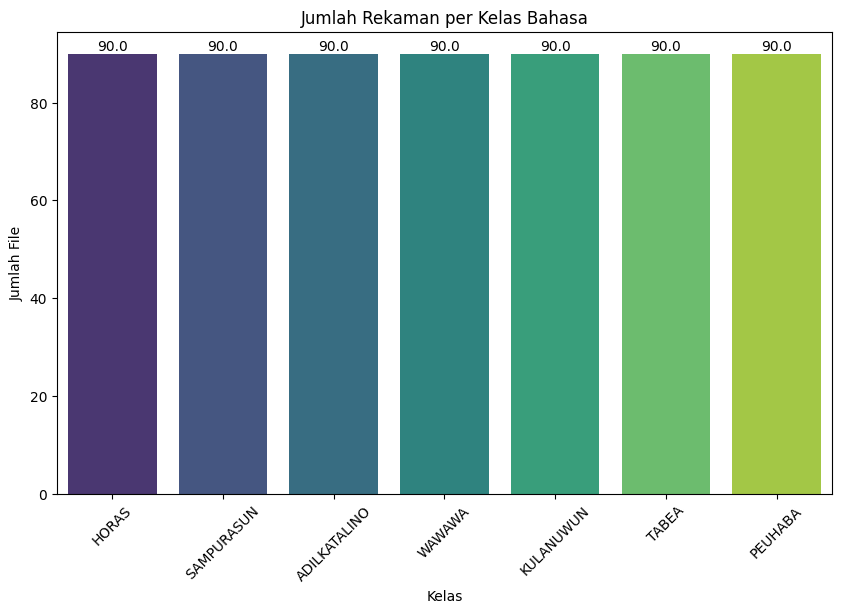

In [9]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Kelas', palette='viridis', order=df['Kelas'].value_counts().index)
plt.title('Jumlah Rekaman per Kelas Bahasa')
plt.ylabel('Jumlah File')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')
plt.show()

### 3. Analisis Durasi Ucapan Asli

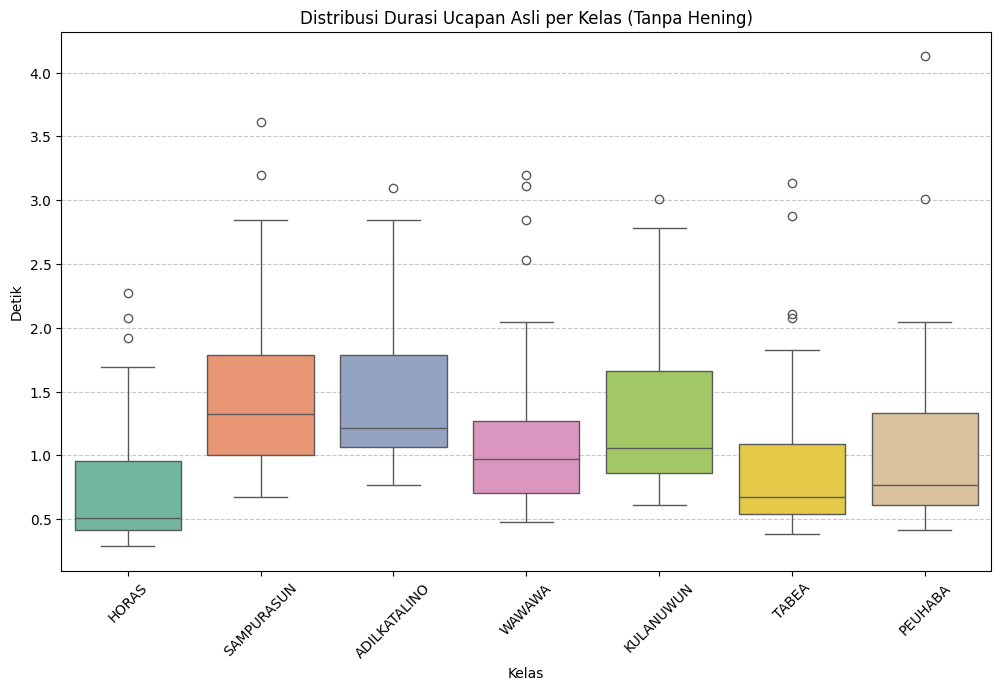

Tabel Statistik Durasi (Detik):


,mean,min,max,std
Kelas,,,,
ADILKATALINO,1.439,0.768,3.093,0.538
HORAS,0.706,0.288,2.272,0.432
KULANUWUN,1.268,0.608,3.008,0.541
PEUHABA,0.997,0.416,4.128,0.567
SAMPURASUN,1.468,0.672,3.616,0.601
TABEA,0.893,0.384,3.136,0.506
WAWAWA,1.089,0.480,3.200,0.566


In [10]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Kelas', y='Durasi Asli Ucapan (s)', palette='Set2')
plt.title('Distribusi Durasi Ucapan Asli per Kelas (Tanpa Hening)')
plt.ylabel('Detik')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Tabel ringkasan statistik durasi
print("Tabel Statistik Durasi (Detik):")
display(df.groupby('Kelas')['Durasi Asli Ucapan (s)'].describe()[['mean', 'min', 'max', 'std']].round(3))

### 4. Analisis Zero-Crossing Rate (ZCR)

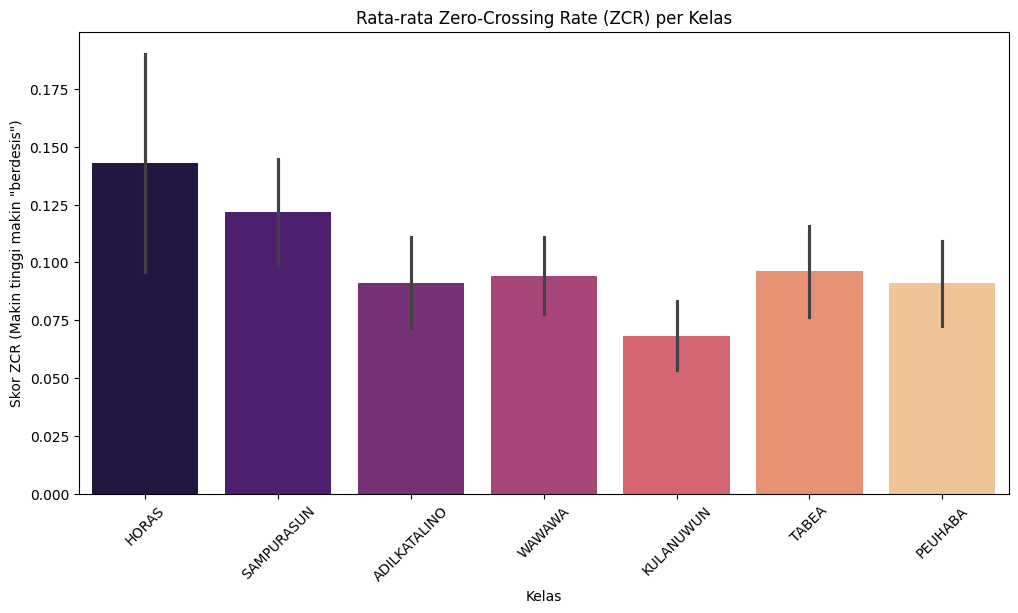

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Kelas', y='ZCR (Kasar/Halus)', palette='magma', ci='sd')
plt.title('Rata-rata Zero-Crossing Rate (ZCR) per Kelas')
plt.ylabel('Skor ZCR (Makin tinggi makin "berdesis")')
plt.xticks(rotation=45)
plt.show()

### 5. Inspeksi Visual (Waveform & Spectrogram)

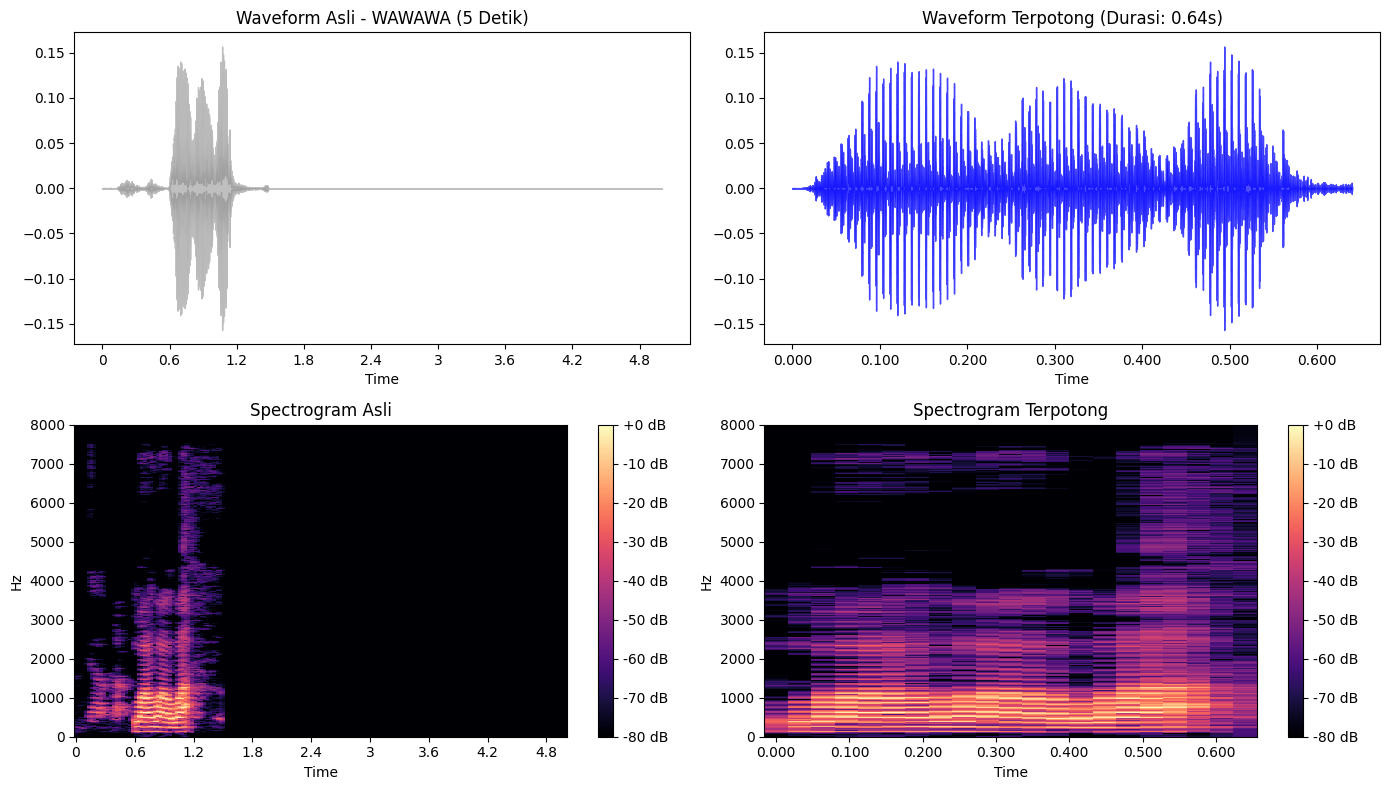

In [12]:
sample = df.sample(1).iloc[0]
y, sr = librosa.load(sample['Path'], sr=16000)
y_trimmed, _ = librosa.effects.trim(y, top_db=20)

plt.figure(figsize=(14, 8))

# 1. Waveform Asli (5 Detik)
plt.subplot(2, 2, 1)
librosa.display.waveshow(y, sr=sr, color='gray', alpha=0.5)
plt.title(f"Waveform Asli - {sample['Kelas']} (5 Detik)")

# 2. Waveform Trimmed
plt.subplot(2, 2, 2)
librosa.display.waveshow(y_trimmed, sr=sr, color='blue', alpha=0.7)
plt.title(f"Waveform Terpotong (Durasi: {sample['Durasi Asli Ucapan (s)']:.2f}s)")

# 3. Spectrogram Asli
plt.subplot(2, 2, 3)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.title('Spectrogram Asli')
plt.colorbar(format='%+2.0f dB')

# 4. Spectrogram Trimmed
plt.subplot(2, 2, 4)
D_trim = librosa.amplitude_to_db(np.abs(librosa.stft(y_trimmed)), ref=np.max)
librosa.display.specshow(D_trim, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.title('Spectrogram Terpotong')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [13]:
raw_dir = 'dataset/augmented'
classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']

data_list = []
print('Mengekstrak data dari seluruh file...')
for folder_name in classes:
    files = glob.glob(os.path.join(raw_dir, folder_name, '*.*'))
    for file in files:
        try:
            y, sr = librosa.load(file, sr=16000)
            raw_duration = len(y) / sr
            y_trimmed, index = librosa.effects.trim(y, top_db=20)
            actual_duration = len(y_trimmed) / sr
            zcr = np.mean(librosa.feature.zero_crossing_rate(y_trimmed))
            data_list.append({
                'Kelas': folder_name.upper(),
                'Durasi Awal (s)': raw_duration,
                'Durasi Asli Ucapan (s)': actual_duration,
                'ZCR (Kasar/Halus)': zcr,
                'Path': file
            })
        except:
            pass

df = pd.DataFrame(data_list)
print(f'Selesai! Berhasil memuat {len(df)} file audio.')
df.head()


Mengekstrak data dari seluruh file...
Selesai! Berhasil memuat 3150 file audio.


,Kelas,Durasi Awal (s),Durasi Asli Ucapan (s),ZCR (Kasar/Halus),Path
0,HORAS,0.426687,0.426687,0.308559,dataset/augmented\horas\horas-01_fast.wav
1,HORAS,0.512000,0.512000,0.321404,dataset/augmented\horas\horas-01_noise.wav
2,HORAS,0.512000,0.512000,0.318790,dataset/augmented\horas\horas-01_ori.wav
3,HORAS,0.512000,0.512000,0.291705,dataset/augmented\horas\horas-01_pitchdown.wav
4,HORAS,0.512000,0.512000,0.338666,dataset/augmented\horas\horas-01_pitchup.wav


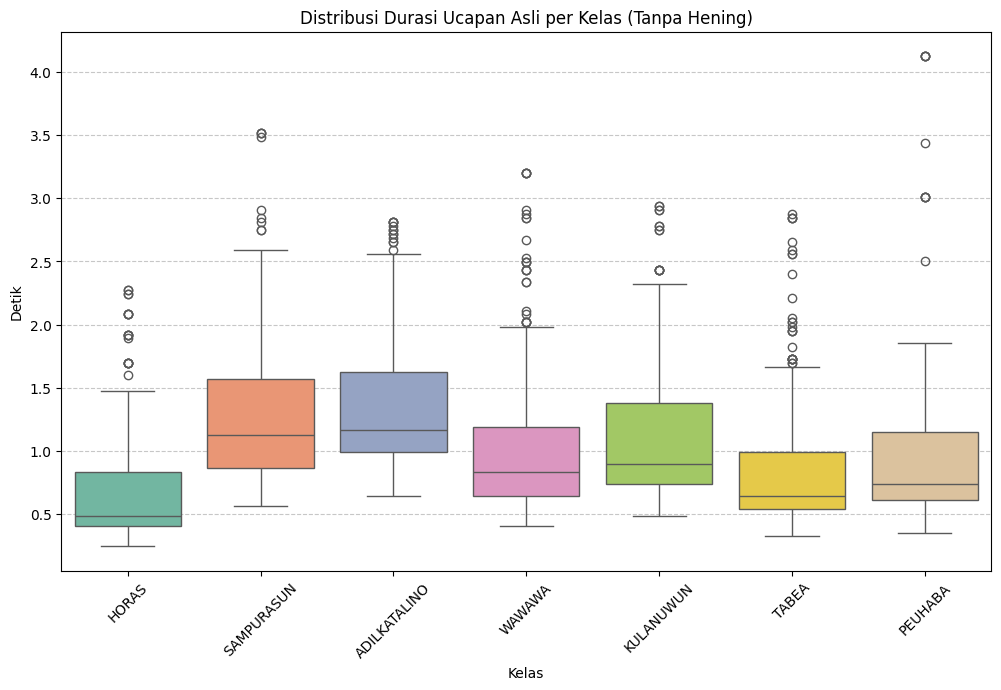

Tabel Statistik Durasi (Detik):


,mean,min,max,std
Kelas,,,,
ADILKATALINO,1.333,0.640,2.816,0.496
HORAS,0.653,0.240,2.272,0.407
KULANUWUN,1.102,0.480,2.944,0.515
PEUHABA,0.924,0.347,4.128,0.528
SAMPURASUN,1.278,0.560,3.520,0.546
TABEA,0.813,0.320,2.880,0.442
WAWAWA,0.993,0.400,3.200,0.509


In [14]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Kelas', y='Durasi Asli Ucapan (s)', palette='Set2')
plt.title('Distribusi Durasi Ucapan Asli per Kelas (Tanpa Hening)')
plt.ylabel('Detik')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Tabel ringkasan statistik durasi
print("Tabel Statistik Durasi (Detik):")
display(df.groupby('Kelas')['Durasi Asli Ucapan (s)'].describe()[['mean', 'min', 'max', 'std']].round(3))